In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [77]:
df = pd.read_csv("insurance.csv")

In [78]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [53]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [54]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [55]:
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [56]:
df.shape

(1338, 7)

In [57]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [58]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [59]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [60]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [61]:
df = pd.read_csv('insurance.csv')

In [62]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [63]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [64]:
le = LabelEncoder()
df['sex']= le.fit_transform(df['sex'])    #female =0, male =1

df['smoker'] = le.fit_transform(df['smoker']) #yes = 0, no =0

In [65]:
df = pd.get_dummies(df, columns=['region'], drop_first=True)

In [66]:
scaler = StandardScaler()
df[['age', 'bmi']] = scaler.fit_transform(df[['age' , 'bmi']])

In [67]:
X = df.drop('charges', axis=1)
y= df['charges']

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

In [69]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1070, 8)
X_test shape: (268, 8)
y_train shape: (1070,)
y_test shape: (268,)


In [70]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("insurance.csv")

# Label Encoding
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])

# One-Hot Encoding
df = pd.get_dummies(df, columns=['region'], drop_first=True)

# Standardization
scaler = StandardScaler()
df[['age', 'bmi']] = scaler.fit_transform(df[['age', 'bmi']])

# Features and Target
X = df.drop('charges', axis=1)
y = df['charges']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1070, 8)
(268, 8)
(1070,)
(268,)


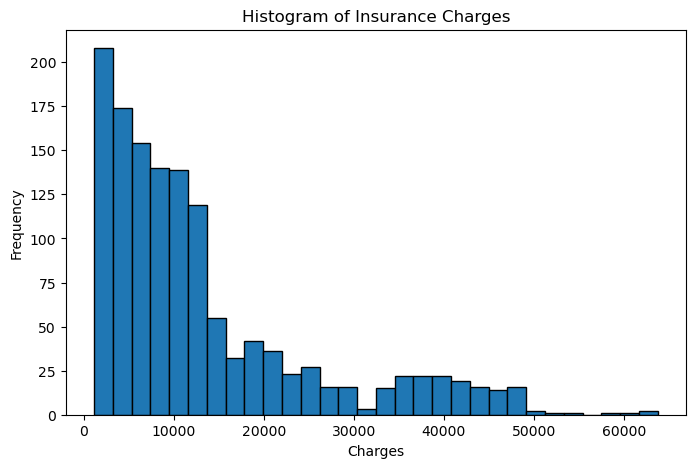

In [71]:
plt.figure(figsize=(8,5))
plt.hist(df['charges'], bins=30, edgecolor='black')
plt.title("Histogram of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

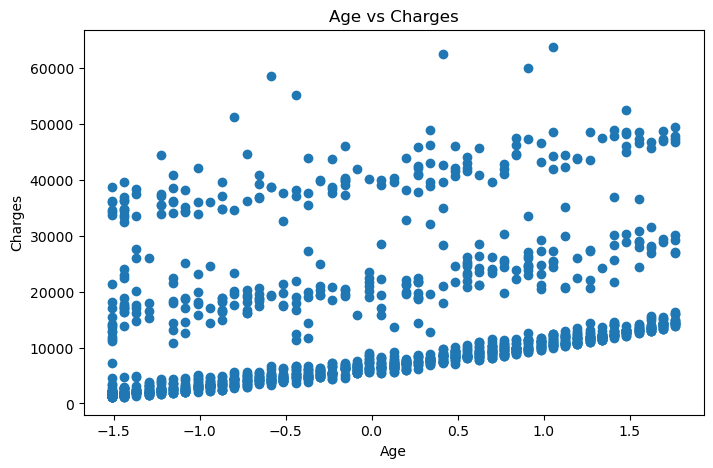

In [72]:
plt.figure(figsize=(8,5))
plt.scatter(df['age'], df['charges'])
plt.title("Age vs Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

smoker
0     8434.268298
1    32050.231832
Name: charges, dtype: float64


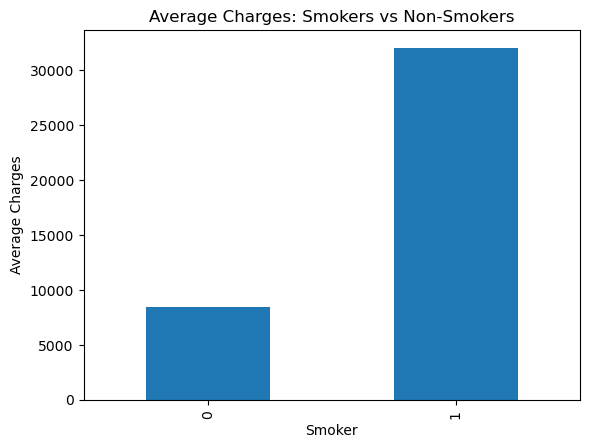

In [73]:
avg_charges = df.groupby('smoker')['charges'].mean()

print(avg_charges)

avg_charges.plot(kind='bar')
plt.title("Average Charges: Smokers vs Non-Smokers")
plt.xlabel("Smoker")
plt.ylabel("Average Charges")
plt.show()

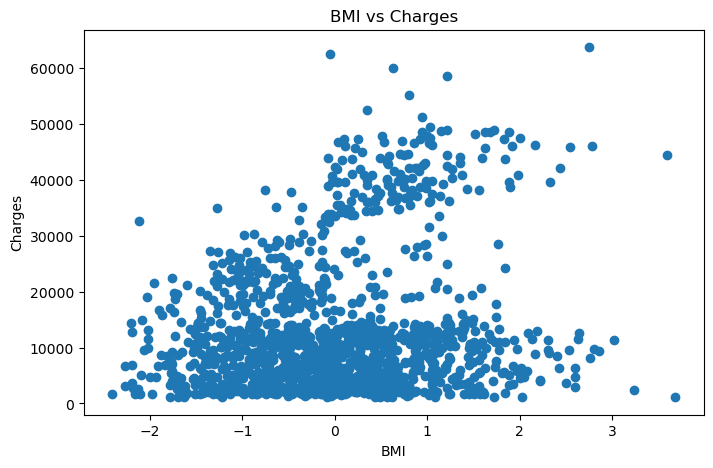

In [74]:
plt.figure(figsize=(8,5))
plt.scatter(df['bmi'], df['charges'])
plt.title("BMI vs Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

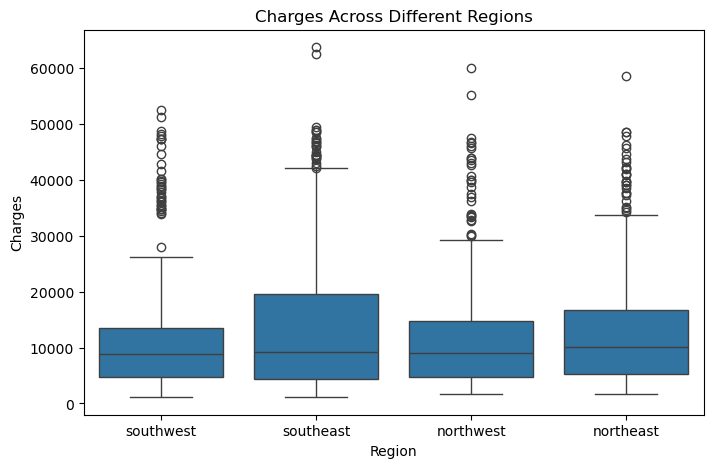

In [79]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_original = pd.read_csv("insurance.csv")

plt.figure(figsize=(8,5))
sns.boxplot(x='region', y='charges', data=df_original)

plt.title("Charges Across Different Regions")
plt.xlabel("Region")
plt.ylabel("Charges")

plt.show()

In [80]:
from sklearn.linear_model import LinearRegression

# Create model
lr = LinearRegression()

# Train model
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [81]:
# Predictions
lr_pred = lr.predict(X_test)

print("First 5 Predictions:")
print(lr_pred[:5])

First 5 Predictions:
[ 8969.55027444  7068.74744287 36858.41091155  9454.67850053
 26973.17345656]


In [82]:
from sklearn.tree import DecisionTreeRegressor

# Create model
dt = DecisionTreeRegressor(random_state=42)

# Train model
dt.fit(X_train, y_train)

# Predictions
dt_pred = dt.predict(X_test)

In [83]:
from sklearn.ensemble import RandomForestRegressor

# Create model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
rf.fit(X_train, y_train)

# Predictions
rf_pred = rf.predict(X_test)

In [84]:
import pandas as pd

comparison = pd.DataFrame({
    'Actual Charges': y_test.values,
    'Linear Regression': lr_pred,
    'Decision Tree': dt_pred,
    'Random Forest': rf_pred
})

print(comparison.head(10))

   Actual Charges  Linear Regression  Decision Tree  Random Forest
0      9095.06825        8969.550274     8615.30000    9627.216016
1      5272.17580        7068.747443     5266.36560    5570.196677
2     29330.98315       36858.410912    28950.46920   28239.647086
3      9301.89355        9454.678501     9225.25640   12468.890214
4     33750.29180       26973.173457    33732.68670   34638.292017
5      4536.25900       10864.113164    11326.71487    8213.784441
6      2117.33885         170.280841     2527.81865    2106.861914
7     14210.53595       16903.450287    14410.93210   14566.864047
8      3732.62510        1092.430936     2974.12600    5647.782606
9     10264.44210       11218.343184    10702.64240   10870.788906


In [85]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

In [86]:
mae_lr = mean_absolute_error(y_test, lr_pred)

print("Linear Regression MAE:", mae_lr)

Linear Regression MAE: 4181.194473753654


In [87]:
mse_lr = mean_squared_error(y_test, lr_pred)

print("Linear Regression MSE:", mse_lr)

Linear Regression MSE: 33596915.85136148


In [88]:
rmse_lr = np.sqrt(mse_lr)

print("Linear Regression RMSE:", rmse_lr)

Linear Regression RMSE: 5796.284659276275


In [89]:
r2_lr = r2_score(y_test, lr_pred)

print("Linear Regression R² Score:", r2_lr)

Linear Regression R² Score: 0.7835929767120722


In [90]:
# Decision Tree Metrics
mae_dt = mean_absolute_error(y_test, dt_pred)
mse_dt = mean_squared_error(y_test, dt_pred)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, dt_pred)

# Random Forest Metrics
mae_rf = mean_absolute_error(y_test, rf_pred)
mse_rf = mean_squared_error(y_test, rf_pred)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, rf_pred)

# Create Comparison Table
comparison = pd.DataFrame({
    'Model': ['Linear Regression',
              'Decision Tree',
              'Random Forest'],
    'MAE': [mae_lr, mae_dt, mae_rf],
    'MSE': [mse_lr, mse_dt, mse_rf],
    'RMSE': [rmse_lr, rmse_dt, rmse_rf],
    'R2 Score': [r2_lr, r2_dt, r2_rf]
})

print(comparison)

               Model          MAE           MSE         RMSE  R2 Score
0  Linear Regression  4181.194474  3.359692e+07  5796.284659  0.783593
1      Decision Tree  3074.866286  4.015399e+07  6336.717525  0.741357
2      Random Forest  2546.095334  2.090826e+07  4572.555223  0.865324


            Feature  Importance
4            smoker    0.608618
2               bmi    0.216500
0               age    0.134203
3          children    0.019463
1               sex    0.006373
5  region_northwest    0.005621
6  region_southeast    0.005284
7  region_southwest    0.003938


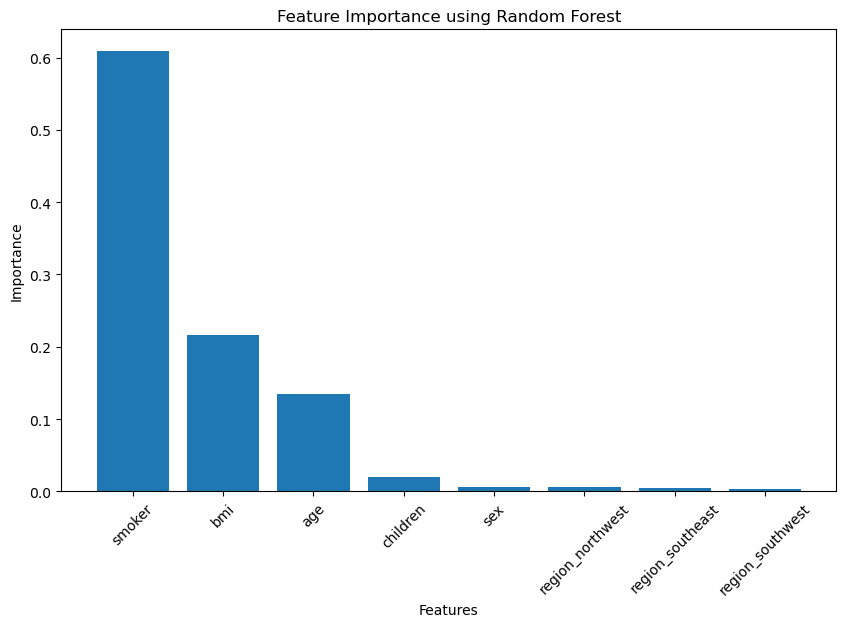

In [91]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance values
importance = rf.feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

# Plot Feature Importance
plt.figure(figsize=(10,6))
plt.bar(feature_importance['Feature'],
        feature_importance['Importance'])

plt.xticks(rotation=45)
plt.title('Feature Importance using Random Forest')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.show()

In [92]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Cross Validation Scores:")
print(cv_scores)

print("Average CV Score:",
      cv_scores.mean())

Cross Validation Scores:
[0.85710999 0.775757   0.86993751 0.82611376 0.85198202]
Average CV Score: 0.8361800576179252


In [93]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Parameter Grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 200}
Best Score:
0.8446651522589802


In [95]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

# Numerical and categorical columns
num_cols = ['age', 'bmi', 'children']
cat_cols = ['sex', 'smoker', 'region']

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ]
)

# Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        random_state=42
    ))
])

# Train pipeline
pipeline.fit(X_train ,
             y_train)

# Predictions
predictions = pipeline.predict(
    X_test_original
)

print(predictions[:5])

ValueError: A given column is not a column of the dataframe

In [96]:
import joblib

# Save Random Forest model
joblib.dump(rf, 'insurance_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [97]:
# Load saved model
loaded_model = joblib.load('insurance_model.pkl')

print("Model loaded successfully!")

Model loaded successfully!
